In [161]:
import pandas as pd
import os
import SensoriMotorPrediction.globals as gl
import seaborn as sb
import numpy as np
import nibabel as nb
import PcmPy as pcm
import matplotlib.pyplot as plt

In [162]:
experiment = 'smp2'
sn = 102
glm = 16
pinfo = pd.read_csv(os.path.join(gl.baseDir, 'smp2', 'participants.tsv'), sep='\t')
FuncRuns = pinfo[pinfo.sn==sn].reset_index()['FuncRuns'][0].split('.')

glm_path = os.path.join(gl.baseDir, 'smp2', f'glm{glm}', f'subj{sn}')
reginfo = pd.read_csv(os.path.join(glm_path, f'subj{sn}_reginfo.tsv'), sep='\t')
reginfo.name = reginfo.name.str.replace(' ', '')
reginfo['BN'] = reginfo['run']
tmp = reginfo['name'].str.split(',', expand=True)
reginfo['cue'] = tmp[0]
reginfo = reginfo[reginfo.name.isin(gl.cues)]

dat = pd.read_csv(os.path.join(gl.baseDir, 'smp2', gl.behavDir, 'behaviour.block.cue.tsv'), sep='\t')
dat_s = dat[(dat.sn==sn) & (dat.BN.astype(str).isin(FuncRuns))].reset_index()
force_df = reginfo.merge(dat_s[['BN', 'cue', 'index0', 'ring0', 'diff0']], on=['BN','cue'], how='left')
cond_vec = force_df['cue'].map(gl.regressor_mapping)
Z = pcm.indicator(cond_vec)
F = force_df[['index0', 'ring0']].to_numpy()
X = np.c_[F, Z]

print(f"X shape: {X.shape}")
print(f"Condition number of X:    {np.linalg.cond(X):.2f}")
print(f"Condition number of F:    {np.linalg.cond(F):.2f}")
print(f"Condition number of Z:    {np.linalg.cond(Z):.2f}")

print("\nCorrelation between F columns and Z columns:")
for fi, fname in enumerate(['index0', 'ring0']):
    for zi, cue in enumerate(gl.cues):
        r = np.corrcoef(F[:, fi], Z[:, zi])[0, 1]
        print(f"  {fname} vs {cue}: r={r:.3f}")

print("\nMean index0 and ring0 per condition:")
for cue in gl.cues:
    m_i = force_df[force_df['cue']==cue]['index0'].mean()
    m_r = force_df[force_df['cue']==cue]['ring0'].mean()
    print(f"  {cue}: index0={m_i:.4f}, ring0={m_r:.4f}")


X shape: (40, 7)
Condition number of X:    3.80
Condition number of F:    1.68
Condition number of Z:    1.00

Correlation between F columns and Z columns:
  index0 vs 100-0%: r=0.011
  index0 vs 75-25%: r=-0.010
  index0 vs 50-50%: r=0.082
  index0 vs 25-75%: r=-0.056
  index0 vs 0-100%: r=-0.027
  ring0 vs 100-0%: r=-0.080
  ring0 vs 75-25%: r=0.067
  ring0 vs 50-50%: r=0.070
  ring0 vs 25-75%: r=-0.128
  ring0 vs 0-100%: r=0.071

Mean index0 and ring0 per condition:
  100-0%: index0=0.0736, ring0=-0.0629
  75-25%: index0=0.0667, ring0=-0.0004
  50-50%: index0=0.0975, ring0=0.0009
  25-75%: index0=0.0514, ring0=-0.0831
  0-100%: index0=0.0608, ring0=0.0011


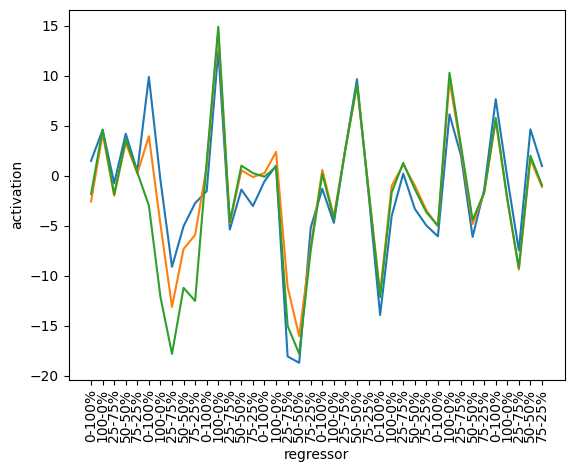

In [163]:
B = nb.load(os.path.join(gl.baseDir, experiment, f'glm{glm}', f'subj{sn}', f'beta.dscalar.nii'))

reginfo = pd.read_csv(os.path.join(gl.baseDir, experiment, f'glm{glm}', f'subj{sn}', f'subj{sn}_reginfo.tsv'), sep='\t')
reginfo.name = reginfo.name.str.replace(' ', '')
reginfo['BN'] = reginfo['run']
tmp = reginfo['name'].str.split(',', expand=True)
reginfo['cue'] = tmp[0]

data = B.get_fdata()[reginfo.name.isin(gl.cues)]

B_ancova = nb.load(os.path.join(gl.baseDir, experiment, f'glm{glm}', f'subj{sn}', f'beta.regr_out_preact_ancova.dscalar.nii'))
data_ancova = B_ancova.get_fdata()

B_ancova_cv = nb.load(os.path.join(gl.baseDir, experiment, f'glm{glm}', f'subj{sn}', f'beta.regr_out_preact_ancova_cv.dscalar.nii'))
data_ancova_cv = B_ancova_cv.get_fdata()

plt.plot(np.nanmean(data,axis=1), label='raw')
plt.plot(np.nanmean(data_ancova, axis=1), label='ancova')
plt.plot(np.nanmean(data_ancova_cv, axis=1), label='ancova_cv')
plt.ylabel('activation')
plt.xlabel('regressor')
labels = reginfo.cue[reginfo.name.isin(gl.cues)]
plt.xticks(range(len(labels)), labels, rotation=90)
plt.show()

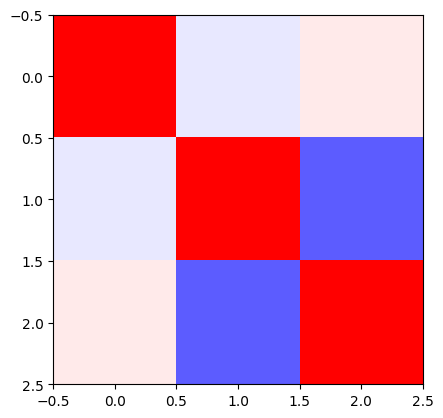

In [164]:
rng = np.random.default_rng(42)
n = 100
p = 1000

# Two loosely correlated regressors (r ~ 0.4)
r = 0.6
cov = np.array([[1, r], [r, 1]])
X_sim = rng.multivariate_normal([0, 0], cov, size=n)
x1, x2 = X_sim[:, 0], X_sim[:, 1]

# Random y (no true signal — just noise)
y = rng.standard_normal((n, p))

# OLS fit
X_des = np.c_[np.ones(n), x1, x2]
b = np.linalg.lstsq(X_des, y, rcond=None)[0]

plt.imshow(np.corrcoef(b), vmin=-1, vmax=1, cmap='bwr')


## Why do correlated regressors get anti-correlated weights?

OLS finds weights $\hat\beta$ by solving:

$$\hat\beta = (X^\top X)^{-1} X^\top y$$

The uncertainty (covariance) of those weights is:

$$\text{Var}(\hat\beta) = \sigma^2 \, (X^\top X)^{-1}$$

For two regressors with correlation $r$, the Gram matrix $X^\top X$ and its inverse look like:

$$X^\top X \;\propto\; \begin{bmatrix} 1 & r \\ r & 1 \end{bmatrix}
\qquad\Longrightarrow\qquad
(X^\top X)^{-1} \;\propto\; \frac{1}{1-r^2}\begin{bmatrix} 1 & -r \\ -r & 1 \end{bmatrix}$$

The **off-diagonal entry** of $(X^\top X)^{-1}$ is $\dfrac{-r}{1-r^2}$.  
This is the covariance between $\hat\beta_1$ and $\hat\beta_2$, and it is **negative whenever $r > 0$**.

### Intuition

When $x_1$ and $x_2$ are correlated, they both point in a similar direction in data space.  
A random $y$ that happens to go in that direction gets explained partly by $x_1$ and partly by $x_2$ — but OLS must split the credit.  
Whichever regressor gets more credit, the other gets less.  
Across many random draws of $y$, this competition makes the two weights **move in opposite directions** → negative covariance.

- At $r = 0$: regressors are orthogonal, weights are independent.  
- As $r \to 1$: regressors are nearly identical, weights become perfectly anti-correlated (and their variance explodes).


In [165]:
rng2 = np.random.default_rng(0)
n_cond, n_part, n_vox, n_channel = 3, 10, 500, 2
n_obs = n_cond * n_part  # 50 = one obs per condition per partition
r_FZ = 0.1  # correlation between F and condition membership

# Each partition contains one observation per condition (like fMRI runs)
cond_vec      = np.tile(np.arange(n_cond), n_part)   # [0,1,2,3,4, 0,1,2,3,4, ...]
part_vec      = np.repeat(np.arange(n_part), n_cond)  # [0,0,0,0,0, 1,1,1,1,1, ...]

Z = np.eye(n_cond)[cond_vec]      # condition indicators (n_obs x n_cond)

# B: true condition effects + noise
B = Z @ rng2.standard_normal((n_cond, n_vox)) + 0.5 * rng2.standard_normal((n_obs, n_vox))

# F: one continuous regressor with controlled correlation to Z
F_signal = Z @ rng2.standard_normal((n_cond, n_channel))  # condition-structured
F_noise  = rng2.standard_normal((n_obs, n_channel))        # random
F = np.sqrt(r_FZ) * F_signal + np.sqrt(1 - r_FZ) * F_noise  #/ F_noise.std(0)

# Simple regression out: project B onto null space of F
B_simple = B - F @ np.linalg.pinv(F) @ B

# ANCOVA: joint model [F, Z], remove only F's contribution
W = np.linalg.pinv(np.c_[F, Z]) @ B
B_ancova = B - F @ W[:n_channel]

import PcmPy as pcm

G, _ = pcm.est_G_crossval(B, cond_vec, part_vec, X=pcm.indicator(part_vec))
print(pcm.G_to_dist(G))

G_simple, _ = pcm.est_G_crossval(B_simple, cond_vec, part_vec, X=pcm.indicator(part_vec))
print(pcm.G_to_dist(G_simple))

G_ancova, _ = pcm.est_G_crossval(B_ancova, cond_vec, part_vec, X=pcm.indicator(part_vec))
print(pcm.G_to_dist(G_ancova))


[[0.         1.89494851 1.99614997]
 [1.89494851 0.         1.98686895]
 [1.99614997 1.98686895 0.        ]]
[[0.         1.23525902 1.03650794]
 [1.23525902 0.         1.95169567]
 [1.03650794 1.95169567 0.        ]]
[[0.         1.92040797 2.0581252 ]
 [1.92040797 0.         1.99425613]
 [2.0581252  1.99425613 0.        ]]


The condition-mean after ANCOVA is:

$$\mu_c(B_{\text{ancova}}) = \mu_c(B) - \underbrace{\bar{F}c}{\neq 0 \text{ in sample}} \cdot W_F$$

Even though $r_{FZ}=0$ in population, in any finite sample $\bar{F}_c \neq 0$ (we saw this: the off-diagonals in $X^\top X$ were ±5). And $W_F$ is also a noisy OLS estimate. The squared distance between two conditions becomes:

$$|\Delta\mu_B - \Delta\bar{F} \cdot W_F|^2 = \underbrace{|\Delta\mu_B|^2}{\text{original}} - 2,\Delta\mu_B \cdot \Delta\bar{F} W_F + \underbrace{|\Delta\bar{F} \cdot W_F|^2}{\text{always} \geq 0}$$

The cross-term averages to zero (independent random quantities), but the last term is always non-negative — it is a systematic positive bias on every sample. This is exactly the noise-inflation problem that crossnobis distances solve via cross-validation.

In [166]:
# Does regressing out x1, x2 increase pairwise distances in y?
# y is (n_obs x n_vox) — each row is a "pattern"
n_obs, n_vox = 50, 200
r = 0.4

X_sim = rng.multivariate_normal([0, 0], [[1, r], [r, 1]], size=n_obs)
X_des = np.c_[np.ones(n_obs), X_sim]

Y = rng.standard_normal((n_obs, n_vox))  # random patterns, no true signal

# Residual maker (I - H)
H = X_des @ np.linalg.inv(X_des.T @ X_des) @ X_des.T
Y_resid = Y - H @ Y

# Pairwise Euclidean distances
from scipy.spatial.distance import pdist
d_orig  = pdist(Y)
d_resid = pdist(Y_resid)

print(f"Mean distance  original: {d_orig.mean():.3f}")
print(f"Mean distance  residual: {d_resid.mean():.3f}")
print(f"Ratio (resid/orig):      {d_resid.mean()/d_orig.mean():.3f}  (always ≤ 1)")


Mean distance  original: 20.014
Mean distance  residual: 19.633
Ratio (resid/orig):      0.981  (always ≤ 1)


In [180]:
def ancova_regress_out_cv(B, F, Z, part_vec):
    """
    Leave-one-partition-out ANCOVA regression.

    For each partition p, estimates the effect of F on B using all
    *other* partitions (jointly with Z), then applies the correction
    to partition p. This avoids leaking partition p's data into its
    own correction, keeping the partitions independent for crossnobis.

    Parameters
    ----------
    B        : (n_obs, n_vox)   data matrix
    F        : (n_obs, n_f)     nuisance regressors to remove
    Z        : (n_obs, n_cond)  condition indicators (kept in model, not removed)
    part_vec : (n_obs,)         integer partition labels

    Returns
    -------
    B_cv : (n_obs, n_vox)  corrected data
    """
    n_f   = F.shape[1]
    B_res  = B.copy()

    for p in np.unique(part_vec):
        train = part_vec != p   # all partitions except p
        test  = part_vec == p   # partition p

        # Remove condition-mean structure from F in both sets
        F_train = F[train]
        F_test  = F[test]

        # Estimate W_F with OLS
        X_train = np.c_[F_train, Z[train]]
        W_train_ols = np.linalg.pinv(X_train) @ B[train]

        # Apply only F's contribution to the test partition
        B_res[test] = B[test] - F_test @ W_train_ols[:n_f]

    return B_res

In [181]:
def ols_regress_out_cv(B, F, part_vec):
    """
    Leave-one-partition-out ANCOVA regression.

    For each partition p, estimates the effect of F on B using all
    *other* partitions (jointly with Z), then applies the correction
    to partition p. This avoids leaking partition p's data into its
    own correction, keeping the partitions independent for crossnobis.

    Parameters
    ----------
    B        : (n_obs, n_vox)   data matrix
    F        : (n_obs, n_f)     nuisance regressors to remove
    part_vec : (n_obs,)         integer partition labels

    Returns
    -------
    B_cv : (n_obs, n_vox)  corrected data
    """
    n_f   = F.shape[1]
    B_res  = B.copy()

    for p in np.unique(part_vec):
        train = part_vec != p   # all partitions except p
        test  = part_vec == p   # partition p

        # Remove condition-mean structure from F in both sets
        F_train = F[train]
        F_test  = F[test]

        # Estimate W_F with OLS
        W_train_ols = np.linalg.pinv(F_train) @ B[train]

        # Apply only F's contribution to the test partition
        B_res[test] = B[test] - F_test @ W_train_ols[:n_f]

    return B_res

In [182]:
import PcmPy as pcm

iterations = 100
r_FZ = 0.05  # correlation between F and condition membership
n_cond, n_part, n_vox, n_channel = 5, 10, 500, 1
n_obs = n_cond * n_part  # 50 = one obs per condition per partition

D, D_simple, D_ols_cv, D_ancova, D_ancova_cv  = [np.zeros(iterations) for _ in range(5)]

for i in range(iterations):

    rng = np.random.default_rng(i)

    # Each partition contains one observation per condition (like fMRI runs)
    cond_vec      = np.tile(np.arange(n_cond), n_part)   # [0,1,2,3,4, 0,1,2,3,4, ...]
    part_vec      = np.repeat(np.arange(n_part), n_cond)  # [0,0,0,0,0, 1,1,1,1,1, ...]

    Z = pcm.indicator(cond_vec)    # condition indicators (n_obs x n_cond)

    # B: true condition effects + noise
    B = rng.standard_normal((n_obs, n_vox))

    # F: one continuous regressor with controlled correlation to Z
    F_correlated = Z @ rng.standard_normal((n_cond, n_channel))  # condition-structured
    F_uncorrelated  = rng.standard_normal((n_obs, n_channel))   # random
    F = np.sqrt(r_FZ) * F_correlated + np.sqrt(1 - r_FZ) * F_uncorrelated  #/ F_noise.std(0)
    F = F - F.mean(axis=0, keepdims=True)

    # Simple regression out: project B onto null space of F
    B_simple = B - F @ np.linalg.pinv(F) @ B

    # ANCOVA: joint model [F, Z], remove only F's contribution
    W = np.linalg.pinv(np.c_[F, Z]) @ B
    B_ancova = B - F @ W[:n_channel]

    # OLS: remove F's contribution in a cross-validated manner
    B_ols_cv = ols_regress_out_cv(B, F, part_vec,)

    # ANCOVA: joint model [F, Z], remove only F's contribution in a cross-validated manner
    B_ancova_cv = ancova_regress_out_cv(B, F, Z, part_vec,)

    G, _ = pcm.est_G_crossval(B, cond_vec, part_vec, X=pcm.indicator(part_vec))
    D[i] = pcm.G_to_dist(G).mean()

    G_simple, _ = pcm.est_G_crossval(B_simple, cond_vec, part_vec, X=pcm.indicator(part_vec))
    D_simple[i] = pcm.G_to_dist(G_simple).mean()

    G_ols_cv, _ = pcm.est_G_crossval(B_ols_cv, cond_vec, part_vec, X=pcm.indicator(part_vec))
    D_ols_cv[i] = pcm.G_to_dist(G_ols_cv).mean()

    G_ancova, _ = pcm.est_G_crossval(B_ancova, cond_vec, part_vec, X=pcm.indicator(part_vec))
    D_ancova[i] = pcm.G_to_dist(G_ancova).mean()

    G_ancova_cv, _ = pcm.est_G_crossval(B_ancova_cv, cond_vec, part_vec, X=pcm.indicator(part_vec))
    D_ancova_cv[i] = pcm.G_to_dist(G_ancova_cv).mean()


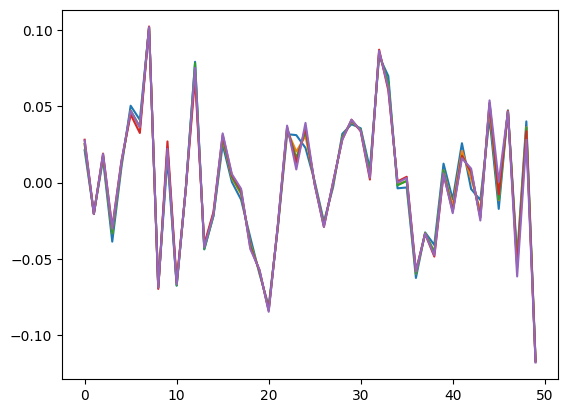

In [184]:
plt.plot(B.mean(axis=1))
plt.plot(B_simple.mean(axis=1))
plt.plot(B_ols_cv.mean(axis=1))
plt.plot(B_ancova.mean(axis=1))
plt.plot(B_ancova_cv.mean(axis=1))

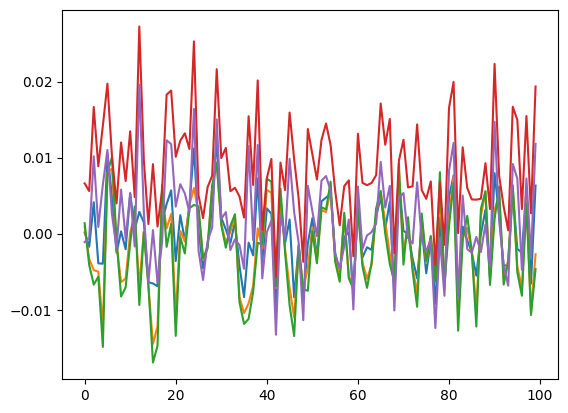

In [185]:
plt.plot(D)
plt.plot(D_simple)
plt.plot(D_ols_cv)
plt.plot(D_ancova)
plt.plot(D_ancova_cv)

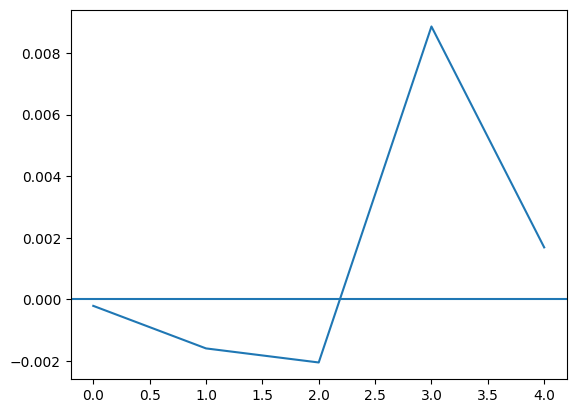

In [186]:
plt.plot(np.array([D.mean(), D_simple.mean(), D_ols_cv.mean(), D_ancova.mean(), D_ancova_cv.mean(), ]))
ax = plt.gca()
ax.axhline(0)

In [136]:
D_ancova_cv.mean()

np.float64(0.0016891543763221115)

In [137]:
D_ancova_ridge.mean()

np.float64(0.001682750077492313)

In [138]:
F.mean(axis=0)

array([2.83106871e-17])